# Family B — does the premium mean-revert intra-quarter?

The question that decides whether dispersion is a POSITION (held to
resolution) or a TRADE (richness fades intra-quarter): per (book, rank),
the daily richness `market premium − tree-fair premium` (fair via the
strict smeared ZQ tree through the MeetingProb pricer), its OU half-life,
and an intra-quarter fade rule that never holds to expiry.

Pre-declared kill: half-life ≥ ~40 sessions ⇒ terminal-only confirmed.

In [1]:
import sys

import numpy as np
import pandas as pd

sys.path.append("../../")
sys.path.append(".")
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from famb_common import (
    TreeCtx, build_book, intra_quarter_backtest, load_quotes, n_contracts,
    ou_half_life, premium_surface, richness_frame, sr3_forwards,
)
from RVUtils.SFRRVLab.stats import nw_tstat

BOOKS = ["FLY25", "STRG50", "DFLY"]
RANKS = [1, 2, 3]

quotes = load_quotes()
symbols = sorted(quotes["symbol"].unique())
fwd = sr3_forwards(symbols)
fwd["as_of"] = pd.to_datetime(fwd["as_of"])
surface = premium_surface(quotes, fwd)
fwd_idx = fwd.set_index(["as_of", "symbol"])["fwd_rate"].sort_index()
dates = pd.DatetimeIndex(sorted(quotes["as_of"].unique()))
tree = TreeCtx([d.date() for d in dates])

books = {}
for book in BOOKS:
    for rank in RANKS:
        books[(book, rank)] = build_book(book, rank, dates, surface,
                                         fwd_idx, tree)

## The richness level and its persistence

`mean(rich)` IS the standing premium vs the lattice (the triangle's
channel-2 object, now in premium bp); the half-life says whether
deviations around it trade.

In [2]:
rows = []
for (book, rank), hs in books.items():
    if not hs:
        continue
    rf = richness_frame(hs)
    if rf.empty:
        continue
    hl, phi, n = ou_half_life(rf)
    rows.append({
        "book": book, "rank": rank, "days": n,
        "mean_rich_bp": round(float(rf["rich_bp"].mean()), 2),
        "sd_rich_bp": round(float(rf["rich_bp"].std()), 2),
        "ar1_phi": round(phi, 3), "half_life_d": round(hl, 1),
    })
persist = pd.DataFrame(rows)
print(persist.to_string(index=False))
terminal_only = persist["half_life_d"].dropna().ge(40).all() \
    if len(persist) else True
print(f"\nall half-lives >= 40 sessions: {terminal_only} -> "
      + ("terminal-only CONFIRMED — intra-quarter trading has nothing to "
         "revert on." if terminal_only else
         "richness DOES revert inside the quarter — the intra-quarter rule "
         "below is a legitimate trade shape."))

  book  rank  days  mean_rich_bp  sd_rich_bp  ar1_phi  half_life_d
 FLY25     1  1084         -0.40        1.91    0.927          9.2
 FLY25     2  1081         -1.59        2.85    0.953         14.6
 FLY25     3  1046         -1.84        3.02    0.948         12.9
STRG50     1  1077          2.88        3.36    0.939         11.0
STRG50     2  1027         12.12        8.05    0.977         29.3
STRG50     3  1005         26.07       12.71    0.984         43.7
  DFLY     1  1080         -0.23        2.60    0.901          6.7
  DFLY     2  1047         -1.11        2.88    0.910          7.4
  DFLY     3  1029         -0.45        3.04    0.921          8.4

all half-lives >= 40 sessions: False -> richness DOES revert inside the quarter — the intra-quarter rule below is a legitimate trade shape.


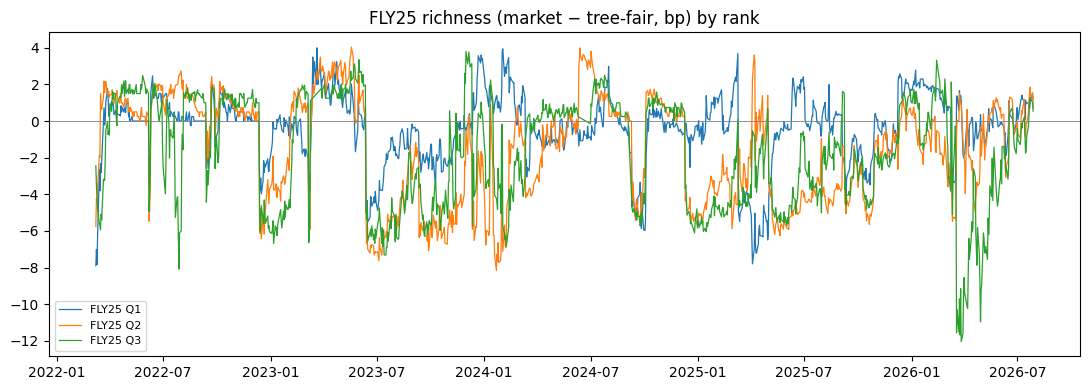

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for (book, rank), hs in books.items():
    if book != "FLY25" or not hs:
        continue
    rf = richness_frame(hs)
    s = rf.groupby("as_of")["rich_bp"].mean()
    ax.plot(s.index, s.values, lw=0.9, label=f"FLY25 Q{rank}")
ax.axhline(0, color="gray", lw=0.6)
ax.set_title("FLY25 richness (market − tree-fair, bp) by rank")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## The intra-quarter rule — trade the deviation, never hold to expiry

Small, pre-declared grid: 3 books × 3 ranks × thr {2,4,6} × both
directions; lag-1, exit at half the entry richness or 15 sessions or the
holding's end. NW t on per-trade nets is optimistic (overlaps across
ranks share days) — read totals and mirrors, not significance.

In [4]:
grid = []
for (book, rank), hs in books.items():
    if not hs:
        continue
    for thr in (2.0, 4.0, 6.0):
        for dirn in ("fade", "momentum"):
            tr = intra_quarter_backtest(
                hs, thr_bp=thr, direction=dirn,
                cost_mult=1.0, n_legs=n_contracts(book))
            if not tr:
                grid.append({"book": book, "rank": rank, "thr": thr,
                             "direction": dirn, "n": 0})
                continue
            nets = np.array([t["net_bp"] for t in tr])
            gross = np.array([t["gross_bp"] for t in tr])
            grid.append({
                "book": book, "rank": rank, "thr": thr, "direction": dirn,
                "n": len(tr), "hit": round(float((nets > 0).mean()), 2),
                "gross_bp": round(float(gross.sum()), 1),
                "net_1x_bp": round(float(nets.sum()), 1),
                "avg_sessions": round(float(np.mean(
                    [t["sessions"] for t in tr])), 1),
            })
g = pd.DataFrame(grid)
live = g[g["n"] > 0]
print(live.sort_values("net_1x_bp", ascending=False).head(14)
      .to_string(index=False))
print("\nsign test (median net@1x by direction): "
      f"{live.groupby('direction')['net_1x_bp'].median().round(1).to_dict()}")
print(f"configs run (for trial accounting): {len(g)}")

  book  rank  thr direction  n  hit  gross_bp  net_1x_bp  avg_sessions
STRG50     1  6.0      fade 19 0.74      40.3       30.8          10.2
STRG50     1  4.0      fade 26 0.73      23.1       10.1          10.2
 FLY25     1  6.0  momentum  3 0.33       1.3       -1.7           6.7
STRG50     2  6.0      fade 61 0.61      26.5       -4.0          12.3
 FLY25     1  6.0      fade  3 0.33      -1.3       -4.3           6.7
 FLY25     1  4.0  momentum  8 0.25       3.1       -4.9           9.4
 FLY25     2  6.0      fade 11 0.27       5.8       -5.2          12.4
  DFLY     1  6.0      fade  7 0.43       7.0       -7.0           8.9
STRG50     1  2.0      fade 50 0.70      14.7      -10.3           9.7
 FLY25     1  4.0      fade  8 0.38      -3.1      -11.1           9.4
 FLY25     3  6.0      fade 13 0.08       1.7      -11.3          11.5
 FLY25     3  6.0  momentum 13 0.15      -1.7      -14.7          11.5
  DFLY     2  6.0      fade 13 0.23       9.6      -16.4           7.2
 FLY25

## Computed answer

The persistence table and the rule grid above answer the question the
spec asked: whether the dispersion premium must be held to quarterly
resolution or reverts tradeably inside the quarter. The findings doc
quotes these numbers.